In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import os


In [3]:
# Define Data URL
MAIN_DIR = "D:\IMAGE2MASS"
IMAGE_DIR = MAIN_DIR + '\\' + 'imagery' + '\\' + 'realsense_overhead'
DISH_DATA_CAFE_1_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe1.csv"
DISH_DATA_CAFE_2_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe2.csv"

In [4]:
# To see the detail of the loading
# Please check the data_loading/loading_tf.ipynb file
# for more details
def load_dataset():
    try:
        cafe1 = pd.read_csv(DISH_DATA_CAFE_1_FILE, header=None, on_bad_lines='skip')
        cafe2 = pd.read_csv(DISH_DATA_CAFE_2_FILE, header=None, on_bad_lines='skip')        
        cafe1 = cafe1.iloc[:, :6]
        cafe2 = cafe2.iloc[:, :6]

        cafe1 = cafe1.dropna()
        cafe2 = cafe2.dropna()
        
        columns = {0: "dish_id", 1: "total_weight", 2: "total_calories", 3: "total_fat", 4: "total_carb", 5: "total_protein"}
        cafe1= cafe1.rename(columns=columns)
        cafe2= cafe2.rename(columns=columns)
        df = pd.concat([cafe1, cafe2], ignore_index=True)
        df["image_path"] = df["dish_id"].apply(lambda x: os.path.join(IMAGE_DIR, x))
        df["image_rgb_path"] = df["image_path"].apply(lambda x: os.path.join(x, "rgb.png"))
        df["image_depth_raw_path"] = df["image_path"].apply(lambda x: os.path.join(x, "depth_raw.png"))
        df["image_depth_color_path"] = df["image_path"].apply(lambda x: os.path.join(x, "depth_color.png"))
        return df
    except Exception as e:
        raise Exception(f"Error loading dataset: {e}")

In [5]:
# Utilities (from data_loading/loading_tf.ipynb)
# create dataset tf Dataset for spliting and further processing
def load_and_preprocess(path, target) -> tuple:
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, target

def create_tf_dataset(dataframe: pd.DataFrame) -> tf.data.Dataset:
    image_paths = dataframe["image_rgb_path"].values
    targets = dataframe[["total_fat", "total_carb", "total_protein"]].values.astype(np.float32)

    # Create a TensorFlow dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))

    # Map the loading and preprocessing function to the dataset
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset

def split_dataset(dataset: tf.data.Dataset, train_size=0.7, val_size=0.15, test_size=0.15) -> tuple:
    assert train_size + val_size + test_size == 1.0, "Train, validation and test sizes must sum to 1.0"

    total_size = len(dataset)
    train_size = int(total_size * train_size)
    val_size = int(total_size * val_size)

    train_dataset = dataset.take(train_size)
    val_dataset = dataset.skip(train_size).take(val_size)
    test_dataset = dataset.skip(train_size + val_size)

    return train_dataset, val_dataset, test_dataset

In [21]:
def create_tf_dataset_and_split(df: pd.DataFrame) -> tuple:
    try:
        df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
        dataset = create_tf_dataset(df_shuffled)        
        return split_dataset(dataset)    
    except Exception as e:
        raise Exception(f"Error creating and splitting dataset: {e}")
    

In [30]:
df = load_dataset() # Load the dataset
df = df[df["image_rgb_path"].apply(os.path.exists)]


In [31]:
train_dataset, val_dataset, test_dataset = create_tf_dataset_and_split(df) # Create and split the dataset

In [32]:
BATCH_SIZE = 32

def batch_datasets(train_ds, val_ds, test_ds, batch_size=BATCH_SIZE):
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds, test_ds

train_dataset, val_dataset, test_dataset = batch_datasets(train_dataset, val_dataset, test_dataset)

In [33]:
# Check si datasets sont batchés
for batch in train_dataset.take(1):
    images, targets = batch
    print(f"Images shape: {images.shape}")  # Doit être (32, 224, 224, 3)
    print(f"Targets shape: {targets.shape}")  # Doit être (32, 3)
    break

Images shape: (32, 224, 224, 3)
Targets shape: (32, 3)


## Model Architecture 
We gonna define multiple architectures to see which one is more efficient

### Self-made architecture
Design a custom architecture as needed. Convolution to analyze images and some layers and tools to optimize the model.

<img src="../diagrams/archi_1.png" width="400">

In [34]:
# i'va already import the keras but i like the simple syntax Seqeuential
# you can to with functional api too
# Yes it's not AI its me hhhhha
# but seriously can use the layers.Input and others functionnal methods from keras API
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D((2, 2)))

model.add(keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.GlobalAveragePooling2D())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.3))

model.add(keras.layers.Dense(3, activation=None))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 batch_normalization_6 (Batc  (None, 222, 222, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 111, 111, 32)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 111, 111, 64)      18496     
                                                                 
 batch_normalization_7 (Batc  (None, 111, 111, 64)     256       
 hNormalization)                                                 
                                                      

In [35]:
# Utilities & Variables for training and evaluation
from keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
# PS: maybe LearningRateScheduler to cutting edged adjustment

log_dir = "../boards/fit/"
EPOCHS = 3 # for testing hein...

early_stopping_loss = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
early_stopping_mae = EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
tensorboard_callback = TensorBoard(log_dir=log_dir,  histogram_freq=1)

In [36]:
# Training the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stopping_loss, early_stopping_mae, lr_scheduler, tensorboard_callback],
    verbose=1
)

import datetime
model_name = "../models/image2macros-" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S") + ".keras"
model.save(model_name)

Epoch 1/3


68/68 [==============================] - 103s 2s/step - loss: 469.1219 - mae: 12.3036 - val_loss: 354.2736 - val_mae: 12.2361 - lr: 0.0010
Epoch 2/3
68/68 [==============================] - 105s 2s/step - loss: 311.6962 - mae: 9.7385 - val_loss: 251.3020 - val_mae: 11.2063 - lr: 0.0010
Epoch 3/3
68/68 [==============================] - 106s 2s/step - loss: 270.2752 - mae: 8.9154 - val_loss: 256.0925 - val_mae: 11.1246 - lr: 0.0010


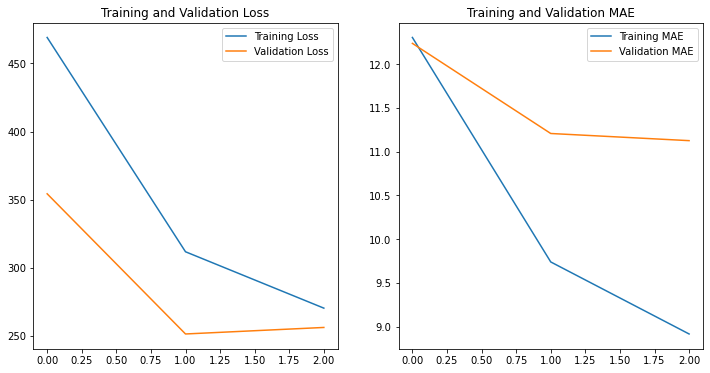

In [37]:
# Loss and mae plots
loss = history.history['loss']
val_loss = history.history['val_loss']

mae = history.history['mae']
val_mae = history.history['val_mae']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, mae, label='Training MAE')
plt.plot(epochs_range, val_mae, label='Validation MAE')
plt.legend(loc='upper right')
plt.title('Training and Validation MAE')

plt.show()

In [38]:
# Evaluating the model
test_loss, test_mae = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

15/15 [==============================] - 15s 539ms/step - loss: 249.0734 - mae: 10.8403
Test Loss: 249.0734100341797, Test MAE: 10.840252876281738


Ps: for see the tensorboard monitoring, follow this :
- pip install tensorboard
- lunch on console : tensorboard --logdir=logs (logs the path)
- open the link http://localhost:6006

Others options will be: wandb (but i don't like hhhha)

### Interpretation
- Loss : good convergence with stable gradient descent
- MAE : mean error around 11g. Test MAE is 10.84g. So prediction are within -/+ 10.84 interval per macro.

### Assessment
Not great but acceptable !

### Action
1) Try hyperparameter finetuning (increase regularization, learningRateScheduler, etc...)
2) Try Transfert Learning
3) Try Data Augmentation